# ViEVOLVEdi

Estudiante: Rodrigo Sebastián Cortez Madrigal

> Music is liquid architecture
--- Johann Wolfgang von Goethe

La composición musical es una forma de arte compleja, altamente creativa y hasta ahora inherentemente humana. Componer implica combinar distintos aspectos musicales como la melodía, la armonía, el ritmo e incluso otros no necesariamente musciales como la emoción, la cultura y la capacidad de innovar dentro de estructuras musicales establecidas. 

Esto hace de la generación automática de música un desafío significativo para los sistemas de inteligencia artificial y que ha sido un problema importante desde hace algunos años en la disciplina. En este trabajo, exploramos el uso de un algoritmo genético para la generación automática de música monofónica, evaluando su capacidad para producir piezas musicales que sean tanto coherentes como creativas.

## Objetivo

El objetivo de *ViEVOLVEdi* es desarrollar un sistema capaz de generar melodías musicales utilizando algoritmos evolutivos. El sistema debe ser capaz de producir melodías que sean musicalmente agradables y variadas, permitiendo a los usuarios configurar diversos parámetros del proceso evolutivo como el rango de notas, la longitud de la melodía, el tamaño de la población, las tasas de cruce y mutación, y el elitismo. 

## Propuesta

Resolver el problema de generación de melodías musicales mediante un algoritmo genético implica definir varios componentes clave: la representación de las melodías (encoding), los operadores genéticos (cruce y mutación) y la función objetivo (fitness function) que evaluará la calidad de las melodías generadas.

### Representación de Melodías

Para entender el encoding utilizado, es importante primero comprender qué es un Standard MIDI File (SMF).

#### Standard MIDI File (SMF)

> No confundir con MIDI, que es un protocolo de comunicación entre instrumentos musicales electrónicos.

Un SMF es un archivo que sigue el estándar MIDI para almacenar estas instrucciones musicales, es decir, notas, ritmo y tempo, en lugar de datos de audio. Los archivos SMF son ampliamente utilizados en la producción musical, la composición y la educación musical debido a su capacidad para representar música de manera compacta y flexible.

Los archivos MIDI estándar pueden estar en estos tres formatos:

- **Formato 0**: Contiene una sola pista que almacena todos los eventos MIDI. Es el formato más simple y se utiliza principalmente para archivos MIDI pequeños o simples.

- **Formato 1**: Contiene múltiples pistas, donde cada pista puede representar diferentes instrumentos o partes de una composición musical. Este formato es más común y permite una mayor complejidad en la representación musical.

- **Formato 2**: También contiene múltiples pistas, pero cada pista puede representar una composición musical independiente. Este formato es menos común y se utiliza principalmente para aplicaciones especializadas.

##### MIDI Formato 0

En nuestro caso, utlizaremos el **Formato 0** para guardar las melodías generadas.

Aquí un ejjemplo de la estructura de un archivo MIDI en Formato 0:

    4D 54 68 64 00 00 00 06 00 00 00 01 00 60
    4D 54 72 6B 00 00 00 19
    00 C0 00
    00 90 3C 64
    81 40 80 3C 40  
    00 FF 2F 00

Un archivo MIDI 0 siempre contiene dos bloques principales:

###### Header Chunk (MThd)

    4D 54 68 64 00 00 00 06 00 00 00 01 00 60

Donde:

- 4D 54 68 64: Identificador del encabezado "MThd"
- 00 00 00 06: Tamaño del encabezado (6 bytes)
- 00 00: Formato del archivo (0)
- 00 01: Número de pistas (1)
- 00 60: División de tiempo (96 ticks por negra)

###### Track Chunk (MTrk) — solo uno (porque es formato 0)


4D 54 72 6B: Identificador "MTrk"
00 00 00 19: Tamaño del track (25 bytes)

Posteriormente, se incluyen los eventos MIDI que definen la melodía.

    00 C0 00           ; [tiempo 0] Program Change → Instrumento 0 (Piano)
    00 90 3C 64        ; [tiempo 0] Note ON → nota 3C (Do4), velocity 100
    81 40              ; delta-time (espera aprox. 192 ticks)
    80 3C 40           ; Note OFF → Do4, velocity 64
    00 FF 2F 00        ; End of Track

Notemos entonces que los eventos, en este caso que son Note ON y Note OFF, están precedidos por un valor de delta-time que indica cuánto tiempo esperar antes de ejecutar el evento, Delta-time + Evento y que es medido en ticks.

Ejemplo: Si el delta-time es 81 40 (en hexadecimal), esto se traduce a 192 ticks. Si la división de tiempo es 96 ticks por negra, entonces 192 ticks equivalen a 2 negras.

### Encoding 

Dado que representar melodías directamente en formato MIDI es complejo, se opta por una representación simplificada para el proceso evolutivo. En el encoding propuesto, cada melodía se representa con una secuencia de pares (nota, duración), donde: - **Nota**: Un valor entero que representa la nota MIDI (por ejemplo, 60 para Do4, 61 para Do#4, etc.). Se utiliza 0 para indicar un silencio. - **Duración**: Un valor flotante que representa la duración rítmica de la nota (por ejemplo, 0.25 para una semicorchea, 0.5 para una corchea, 1.0 para una negra, etc.).

Utilizamos la siguiente clase para el encoding que hereda de la clase base `Encoding` de MetaZoo.

```python
class MelodyEncoding(Encoding):
    """
    Codifica una melodía como una secuencia de notas MIDI y duraciones rítmicas, incluyendo silencios.
    Usa 0 como nota para indicar silencio.
    """
    def __init__(self, note_range: Tuple[int, int] = (60, 72), durations: Tuple[float, ...] = (0.25, 0.5, 1.0, 2.0), length: int = 64, silence_prob: float = 0.2):
        self.note_range = note_range
        self.durations = durations
        self.length = length
        self.genome_length = length
        self.silence_prob = silence_prob

    def encode(self, population_size: int) -> np.ndarray:
        notes = np.random.randint(self.note_range[0], self.note_range[1], size=(population_size, self.length))
        # Asigna silencios aleatoriamente
        silence_mask = np.random.rand(population_size, self.length) < self.silence_prob
        notes[silence_mask] = 0
        durations = np.random.choice(self.durations, size=(population_size, self.length))
        return np.stack((notes, durations), axis=-1)

    def decode(self, individual: np.ndarray) -> np.ndarray:
        return individual
```

Notemos que para la generación inicial de la población, lo hacemos de manera aleatoria, asignando notas dentro del rango especificado y duraciones de una lista predefinida. Además, se introduce una probabilidad de silencio para diversificar las melodías.

Entonces, un individuo de la población podría verse así:

```python

array([[71.  ,  0.5 ],
       [64.  ,  2.  ],
       [61.  ,  1.  ],
       [ 0.  ,  1.  ],
       [66.  ,  1.  ],
       [65.  ,  0.25],
       [66.  ,  0.25],
       [69.  ,  0.25],
       [65.  ,  2.  ],
       [67.  ,  0.25],
       [ 0.  ,  0.25],
       [65.  ,  0.5 ],
       [64.  ,  0.25],
       [71.  ,  0.25],
       [60.  ,  2.  ],
       [ 0.  ,  1.  ]])

```

### Operadores Genéticos

Ahora necesitamos implementar operadores de cruce y mutación específicos para este tipo de encoding. El cruce combina segmentos de dos melodías padres, mientras que la mutación altera aleatoriamente notas o duraciones en una melodía.

```python
class MelodyOperators:
    @staticmethod
    def crossover(parent1, parent2):
        # Dos puntos de corte para mayor variedad
        p1, p2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
        child1 = np.vstack((parent1[:p1], parent2[p1:p2], parent1[p2:]))
        child2 = np.vstack((parent2[:p1], parent1[p1:p2], parent2[p2:]))
        return child1, child2

    @staticmethod
    def mutation(individual, note_range=(60,72), durations=(0.25,0.5,1.0,2.0), silence_prob=0.05):
        idx = np.random.randint(len(individual))
        # Evita mutar a silencio si ya hay muchos
        if np.random.rand() < silence_prob and sum(individual[:,0]==0)/len(individual) < 0.3:
            individual[idx, 0] = 0
        else:
            individual[idx, 0] = np.random.randint(note_range[0], note_range[1])
        individual[idx, 1] = np.random.choice(durations)
        return individual
```

El cross over utiliza dos puntos de corte para combinar segmentos de dos padres y crear dos hijos. La mutación selecciona una posición aleatoria en la melodía y cambia la nota o duración, con una probabilidad de introducir un silencio, siempre y cuando no haya demasiados silencios ya presentes.

### Función Objetivo

La función objetivos es el "corazón" del proceso evolutivo, ya que define qué tan "buena" es una melodía generada. Optimizar una melodía implica evaluar múltiples aspectos musicales que contribuyen a su calidad percibida, por lo que se trata inherentemente de un problema multiobjetivo. 

A continuación, se describen los algunos aspectos musicales que se consideran en la función objetivo:

- **Diversidad**: Variedad de notas utilizadas en la melodía.
- **Variación rítmica**: Diversidad en las duraciones de las notas.
- **Rango de alturas**: Diferencia entre la nota más alta y la más baja.
- **Densidad temporal**: Cantidad de notas por unidad de tiempo.
- **Variación de contorno**: Cambios en la dirección melódica (ascendente/descendente).
- **Variedad intervalica**: Diversidad de intervalos entre notas consecutivas.
- **Índice de sincopación**: Presencia de ritmos sincopados.
- **Estabilidad tonal**: Proximidad a una tonalidad específica.
- **Repetición motívica**: Presencia de motivos melódicos repetidos.
- **Estructura de frases**: Organización de la melodía en frases coherentes.
- **Tensión y liberación**: Uso de notas que crean tensión y su resolución.
- **Variación de articulación**: Diferentes formas de tocar las notas (legato, staccato, etc.).
- **Rango dinámico**: Variedad en la intensidad de las notas.
- **Pausas silenciosas**: Uso efectivo de silencios en la melodía.
- **Relación armónica**: Coherencia con una progresión armónica subyacente. 
- **Repetición excesiva**: Penalización por repetición excesiva de patrones.
- **Resolución melódica**: Presencia de resoluciones melódicas satisfactorias.

Si quisieramos resolver este problema como un problema de optimización multiobjetivo, esto implicaría evaluar cada uno de estos aspectos por separado y luego utilizar un enfoque como NSGA-II para encontrar un conjunto de soluciones que representen un buen compromiso entre los distintos objetivos. No obstante, el espacio de soluciones se vuelve muy grande y difícil de explorar eficientemente pues estamos ante un problema de optimización con al menos 17 objetivos según este planteamiento. El espacio de búsqueda se vuelve enorme y la convergencia hacia soluciones óptimas se dificulta considerablemente.

Otro enfoque que podemos seguir para simplificar el problema es combinar estos múltiples objetivos en una única función de aptitud compuesta. Esto se logra asignando pesos a cada uno de los aspectos musicales según su importancia relativa y luego sumando sus contribuciones ponderadas para obtener una única puntuación de aptitud para cada melodía generada.

No obstante, esto tampoco es sencillo ni directa y a que encontramos problemas asociados a los distintos rangos de valores que pueden tomar los distintos subobjetivos. Para abordar esto, la mayoría de los subobjetivos se normalizan a un rango común (por ejemplo, 0 a 1) antes de combinarlos. No obstante, algunos subojetivos no pueden ser normalizados de manera sencilla, por lo que se asignan pesos más bajos para reducir su impacto relativo en la función objetivo global. Esto permite que todos los aspectos contribuyan de manera equilibrada a la evaluación final de la melodía.

```python
class ScoreFitness:
    def __init__(self, weights=None):
        if weights is None:
            self.weights = [
                1.0,    # Diversity
                1.0,    # Rhythmic Variation
                1.0,    # Pitch Range
                1.0,    # Temporal Density
                1.0,    # Contour Variation
                1.0,    # Intervallic Variety
                1.0,    # Syncopation Index
                1.0,    # Tonal Stability
                0.1,    # Motivic Repetition
                0.5,    # Phrase Structure
                0.05,   # Tension Release
                1.0,    # Articulation Variation
                0.01,   # Dynamic Range
                1.0,    # Silent Beats
                0.01,   # Harmonic Relation
                1.0,    # Excessive Repetition
                0.1,    # Melodic Resolution
            ]
        else:
            self.weights = weights

    def eval(self, melody):
        scores = [
            self.diversity(melody),
            self.rhythmic_variation(melody),
            self.pitch_range(melody),
            self.temporal_density(melody),
            self.contour_variation(melody),
            self.intervallic_variety(melody),
            self.syncopation_index(melody),
            self.tonal_stability(melody),
            self.motivic_repetition(melody),
            self.phrase_structure(melody),
            self.tension_release(melody),
            self.articulation_variation(melody),
            self.dynamic_range(melody),
            self.silent_beats(melody),
            self.harmonic_relation(melody),
            self.excessive_repetition(melody),
            self.melodic_resolution(melody),
        ]
        return scores * np.array(self.weights)

    @staticmethod
    def diversity(melody):
        """
        DIVERSIDAD
        Descripción: Regresa el número de pares únicos (nota, duración) en la melodía normalizada.
        Normaliza dividiendo por la longitud total de la melodía.
        Rango: [0, 1].
        """
        if len(melody) == 0:
            return 0
        return len(set(tuple(pair) for pair in melody)) / len(melody)

    @staticmethod
    def rhythmic_variation(melody):
        """
        VARIACIÓN RÍTMICA
        Descripción: Regresa la variedad rítmica como la proporción de duraciones únicas sobre el total de duraciones.
        Normaliza dividiendo por la longitud total de la melodía.
        Rango: [0, 1].
        """
        durations = [float(duration) for note, duration in melody]
        return len(set(durations)) / len(durations) if durations else 0

    @staticmethod
    def pitch_range(melody):
        """
        RANGO DE PITCH
        Descripción: Calcula el rango de pitch (diferencia entre la nota más alta y la más baja).
        Ignora silencios (notas = 0). Regresa 0 si no hay notas.
        Normaliza dividiendo por 127 (rango MIDI completo).
        Rango: [0, 1].
        """
        pitches = [float(note) for note, duration in melody if note > 0]
        return (max(pitches) - min(pitches)) / 127 if pitches else 0

    @staticmethod
    def temporal_density(melody):
        """
        DENSIDAD TEMPORAL
        Descripción: Calcula la densidad temporal, que es el número de notas por unidad de tiempo.
        Rango: [0, ∞).
        """
        total_duration = sum(
            float(duration) for note, duration in melody
        )  # Duración total
        return (
            len(melody) / total_duration if total_duration > 0 else 0
        )  # Notas por unidad de tiempo

    @staticmethod
    def contour_variation(melody):
        """
        VARIACIÓN DE CONTORNO
        Descripción: Calcula la variación del contorno melódico como el número de cambios de dirección (ascendente, descendente, igual).
        Regresa el número de cambios de dirección únicos.
        Normaliza dividiendo por 2 (máximo número de cambios únicos).
        Rango: [0, 1].
        """
        contour = []
        for i in range(1, len(melody)):
            if melody[i][0] > melody[i - 1][0]:
                contour.append(1)  # Ascendente
            elif melody[i][0] < melody[i - 1][0]:
                contour.append(-1)  # Descendente
            else:
                contour.append(0)  # Igual
        return len(set(contour)) / 2 if contour else 0

    @staticmethod
    def intervallic_variety(melody, max_interval=12):
        """
        VARIEDAD INTERVALICA
        Calcula la variedad intervalica como el número de intervalos únicos entre notas consecutivas.
        Penaliza saltos mayores a max_interval (por defecto, una octava).
        Ignora silencios (notas = 0).
        Normaliza dividiendo por 12 (número de semitonos en una octava).
        Rango: [0, 1], pero puede ser negativo si hay muchos saltos grandes.
        """
        intervals = set()
        penalty = 0
        for i in range(1, len(melody)):
            if melody[i][0] > 0 and melody[i - 1][0] > 0:
                interval = abs(melody[i][0] - melody[i - 1][0])
                intervals.add(interval)
                if interval > max_interval:
                    penalty += 1
        score = (
            len(intervals) / 12 - penalty * 0.1
        )  # penaliza cada salto grande con -0.1
        return max(score, 0)  # asegura que no sea negativo

    @staticmethod
    def syncopation_index(melody):
        """
        ÍNDICE DE SINCOPACIÓN
        Descripción: Calcula un índice simple de sincopación contando notas en tiempos débiles (duraciones menores a 1.0).
        Normaliza dividiendo por la longitud total de la melodía.
        Rango: [0, 1].
        """
        syncopation = 0
        for note, duration in melody:
            if note > 0 and duration < 1.0:  # Nota en tiempo débil
                syncopation += 1
        return syncopation / len(melody) if len(melody) > 0 else 0

    @staticmethod
    def tonal_stability(melody, key_center=60):
        """
        ESTABILIDAD TONAL
        Descripción: Calcula la estabilidad tonal contando notas que pertenecen a la tonalidad mayor (tónica, tercera mayor, quinta).
        Normaliza dividiendo por la longitud total de la melodía.
        Rango: [0, 1].
        """
        stability = 0
        for note, duration in melody:
            if note > 0:
                interval = abs(note - key_center) % 12
                if interval in [0, 4, 7]:  # Notas estables en la tonalidad mayor
                    stability += 1
        return stability / len(melody) if len(melody) > 0 else 0

    @staticmethod
    def motivic_repetition(melody, motif_length=4):
        """
        REPETICIÓN MOTÍVICA
        Descripción: Cuenta cuántas veces se repiten motivos de longitud motif_length en la melodía.
        Penaliza si no hay repeticiones.
        """
        motifs = {}
        for i in range(len(melody) - motif_length + 1):
            motif = tuple(map(tuple, melody[i : i + motif_length]))
            if motif in motifs:
                motifs[motif] += 1
            else:
                motifs[motif] = 1
        repetitions = sum(count - 1 for count in motifs.values() if count > 1)
        return repetitions if repetitions > 0 else -100

    @staticmethod
    def phrase_structure(melody, phrase_length=16):
        """
        ESTRUCTURA DE FRASE
        Descripción: Cuenta el número de frases únicas en la melodía.
        Una frase es una secuencia de phrase_length notas.
        phrase_length: cuántas notas por frase
        Regresa el número de frases únicas.
        """
        phrases = [
            tuple(map(tuple, melody[i : i + phrase_length]))
            for i in range(0, len(melody), phrase_length)
        ]
        unique_phrases = set(phrases)
        return len(unique_phrases)

    @staticmethod
    def tension_release(melody):
        """
        TENSIÓN Y RESOLUCIÓN
        Descripción: Calcula la tensión basada en ascensos y descensos en la melodía.
        Ascensos generan tensión, descensos liberan tensión.
        Regresa el valor absoluto de la tensión acumulada.
        Rango: En (-len(melody), len(melody)).
        """
        tension = 0
        for i in range(1, len(melody)):
            if melody[i][0] > melody[i - 1][0]:
                tension += 1  # Ascenso genera tensión
            elif melody[i][0] < melody[i - 1][0]:
                tension -= 1  # Descenso libera tensión
        return abs(tension)

    @staticmethod
    def articulation_variation(melody):
        """
        VARIACIÓN DE ARTICULACIÓN
        Descripción: Cuenta el número de tipos de articulación presentes en la melodía (staccato, legato).
        Asume que duraciones <= 0.5 son staccato y > 0.5 son legato.
        Regresa el número de tipos de articulación.
        Rango: [0, 1].
        """
        articulations = set()
        for note, duration in melody:
            if note > 0:
                if duration <= 0.5:
                    articulations.add("staccato")
                else:
                    articulations.add("legato")
        return len(articulations) / 2  # Normaliza por 2 tipos posibles

    @staticmethod
    def dynamic_range(melody, base_velocity=100):
        """
        RANGO DINÁMICO
        Descripción: Calcula el rango dinámico basado en la variación de velocidades asignadas a las notas.
        Asume una velocidad base para todas las notas y calcula la variación.
        Regresa la diferencia entre la velocidad máxima y mínima.
        Rango: [0, ∞).
        """
        velocities = []
        for note, duration in melody:
            if note > 0:
                velocities.append(base_velocity)
            else:
                velocities.append(0)
        return max(velocities) - min(velocities)

    @staticmethod
    def silent_beats(melody):
        """
        SILENCIOS
        Descripción: Cuenta el número de silencios (notas con valor 0) en la melodía.
        Regresa el número de silencios.
        Rango: (-∞, 0].
        """
        silent_count = sum(1 for note, duration in melody if note == 0)

        return -silent_count

    @staticmethod
    def harmonic_relation(
        melody,
        chords=[(60, 64, 67), (67, 71, 74), (69, 72, 76), (65, 69, 72)],
        phrase_length=4,
    ):
        """
        RELACIÓN ARMÓNICA
        Descripción: Premia notas que coinciden con las notas de los acordes dados.
        chords: lista de acordes como tuplas de notas MIDI.
        phrase_length: número de notas por frase para asignar acordes.
        Regresa el número de notas que coinciden con las notas de los acordes.
        Rango: [0, ∞).
        """
        score = 0
        for i, (note, duration) in enumerate(melody):
            if note == 0:
                continue
            chord = chords[(i // phrase_length) % len(chords)]
            if note % 12 in [n % 12 for n in chord]:
                score += 1
        return score

    @staticmethod
    def excessive_repetition(melody, max_repeats=3):
        """
        REPETICIÓN EXCESIVA
        Descripción: Penaliza si una nota se repite más de max_repeats veces consecutivamente.
        Regresa una penalización negativa proporcional al exceso de repeticiones.
        Rango: (-∞, 0].
        """
        penalty = 0
        count = 1
        last_note = None
        for note, duration in melody:
            if note == last_note and note != 0:
                count += 1
                if count > max_repeats:
                    penalty += 1
            else:
                count = 1
            last_note = note
        return -penalty

    @staticmethod
    def melodic_resolution(melody, tonic=60):
        """
        RESOLUCIÓN MELÓDICA
        Descripción: Premia si la última nota no silenciosa es la tónica.
        Regresa 1 si la última nota no silenciosa es la tónica, de lo contrario 0.
        Rango: [0, 1].
        """
        for note, duration in reversed(melody):
            if note > 0:
                return 1 if note % 12 == tonic % 12 else 0
        return 0

    def fitness_function(self, melody):
        """
        Función de fitness total que suma todas las sub-métricas ponderadas.
        """
        return self.eval(melody).sum()

    def plot(self, melody):
        scores = self.eval(melody)
        aspects = [
            ("Diversity", scores[0]),
            ("Rhythmic Variation", scores[1]),
            ("Pitch Range", scores[2]),
            ("Temporal Density", scores[3]),
            ("Contour Variation", scores[4]),
            ("Intervallic Variety", scores[5]),
            ("Syncopation Index", scores[6]),
            ("Tonal Stability", scores[7]),
            ("Motivic Repetition", scores[8]),
            ("Phrase Structure", scores[9]),
            ("Tension Release", scores[10]),
            ("Articulation Variation", scores[11]),
            ("Dynamic Range", scores[12]),
            ("Silent Beats", scores[13]),
            ("Harmonic Relation", scores[14]),
            ("Excessive Repetition", scores[15]),
            ("Melodic Resolution", scores[16]),
        ]
        labels = [a[0] for a in aspects]
        values = [a[1] for a in aspects]
        labels += [labels[0]]
        values += [values[0]]
        fig = go.Figure(
            data=[
                go.Scatterpolar(r=values, theta=labels, fill="toself", name="Aspectos")
            ]
        )
        fig.update_layout(
            polar=dict(radialaxis=dict(visible=True)),
            showlegend=False,
            title="Perfil de Fitness de la Melodía",
        )
        return fig
```

#### Poniendo todo junto

Una vez definidas las clases de encoding, operadores genéticos y función objetivo, podemos configurar y ejecutar el algoritmo genético utilizando MetaZoo.

El resultado final será una melodía generada evolutivamente que puede ser exportada como un archivo MIDI para su reproducción y análisis musical. Se añade la opción de renderizar la partitura utilizando bibliotecas como `music21` y `MIDIUtil` para una visualización más intuitiva de la melodía generada.


## Resultados

In [1]:
# Core libraries
import os
import sys 

# MIDI and MusicXML handling
from music21 import converter, environment

# Plotly configuration
import plotly.io as pio
pio.renderers.default = "svg"

# MetaZoo 
from metazoo.bio.evolutionary import GeneticAlgorithm
from metazoo.bio.evolutionary.operators import selection
from metazoo.bio.utils import Population

# Utils 

from melody_encoding import MelodyEncoding
from utils import melody_to_midi
from fitness import ScoreFitness
from operators import MelodyOperators

In [2]:
# MIDI and MusicXML settings

us = environment.UserSettings()

if sys.platform.startswith("darwin"):
    us['musicxmlPath'] = '/Applications/MuseScore 4.app/Contents/MacOS/mscore'
    us['musescoreDirectPNGPath'] = '/Applications/MuseScore 4.app/Contents/MacOS/mscore'
    SAVE_PATH = os.path.join(os.getcwd(), "generated")
if sys.platform.startswith("linux"):
    us['musicxmlPath'] = '/usr/bin/musescore'
    us['musescoreDirectPNGPath'] = '/usr/bin/musescore'
    SAVE_PATH = os.path.join('/tmp', 'generated')

# Save Path
os.makedirs(SAVE_PATH, exist_ok=True)

In [3]:
encoding = MelodyEncoding(note_range=(60, 72), length=16)
population = Population(population_size=100, encoding=encoding)

In [4]:
population.individuals[0]

array([[65.  ,  2.  ],
       [61.  ,  0.25],
       [64.  ,  1.  ],
       [ 0.  ,  2.  ],
       [ 0.  ,  2.  ],
       [63.  ,  0.25],
       [71.  ,  2.  ],
       [61.  ,  0.5 ],
       [68.  ,  0.25],
       [ 0.  ,  1.  ],
       [ 0.  ,  1.  ],
       [67.  ,  1.  ],
       [ 0.  ,  0.5 ],
       [ 0.  ,  1.  ],
       [71.  ,  1.  ],
       [ 0.  ,  0.25]])

Observamos un individuo generado de manera aleatoria y su evaluación según la función objetivo. Naturalmente si calculamos el fitness de este individuo, obtenemos valores bajos en la mayoría de los criterios, reflejando la falta de estructura musical en una melodía generada al azar.

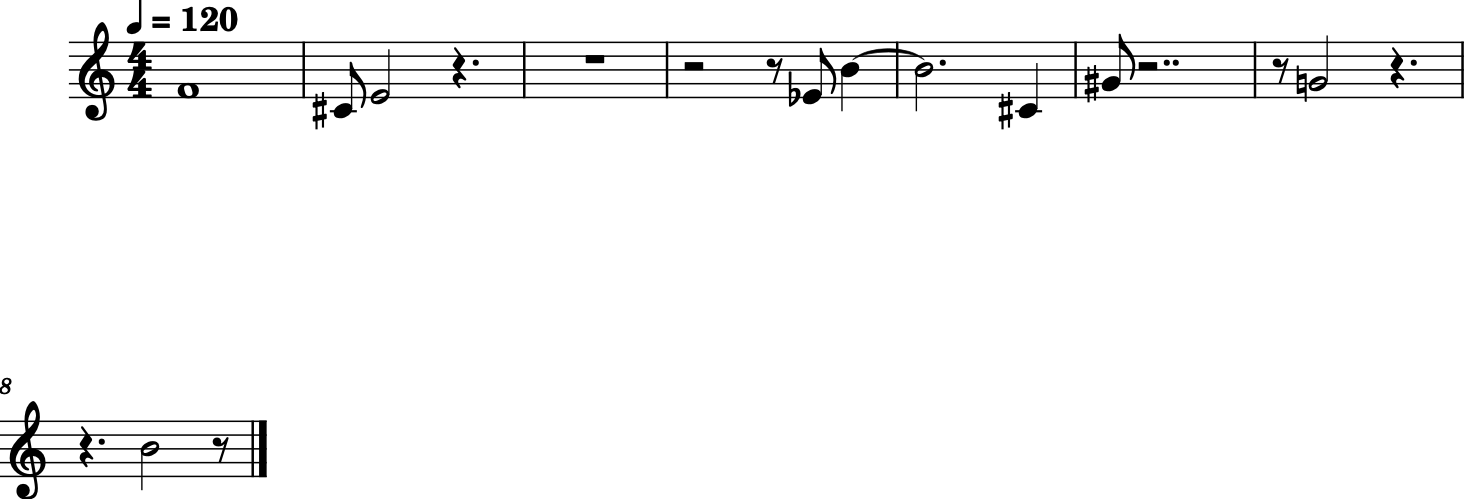

In [5]:
melody = population.individuals[0]
midi_file = melody_to_midi(melody)
score = converter.parse(midi_file)
score.show()
# delete melody.mid file
os.remove("melody.mid")

In [6]:
fitness = ScoreFitness()
fitness.plot(melody)

### Algoritmo Genético para la Evolución de Melodías

In [7]:
class MelodyGA(GeneticAlgorithm):
    def __init__(self, *args, **kwargs):
        kwargs['minimize'] = False
        super().__init__(*args, **kwargs)

In [8]:
ga = MelodyGA(
    fitness_function=fitness.fitness_function,
    selection_function=selection.tournament,
    crossover_function=MelodyOperators.crossover,
    mutation_function=MelodyOperators.mutation,
    crossover_rate=0.7,
    mutation_rate=0.1,
    encoder=MelodyEncoding(note_range=(60, 72), length=128),
    elitism=0.1
)

In [9]:
ga.run(generations=500)

Output()

#### Convergencia del Algoritmo Genético

Podemos ver que el algoritmo genético converge correctamente, mejorando la aptitud promedio de la población a lo largo de las generaciones. Esto indica que las melodías generadas evolucionan hacia soluciones más "agradables" según los criterios definidos enteramente por la función objetivo. Es notable que algunos criterios mejoran más rápidamente que otros, lo que sugiere que ciertos aspectos musicales son más fáciles de optimizar mediante el proceso evolutivo. De hecho observamos que la diversidad y la variación rítmica tienden a mejorar rápidamente, mientras que aspectos como la estabilidad tonal y la estructura de frases muestran una mejora más gradual. Esto podría deberse a la complejidad inherente de estos aspectos musicales, que requieren una mayor coherencia y organización en la melodía. Esto se nota en que el alhoritmos parte también de valores negativos que son las penalizaciones por no cumplir ciertos criterios, como los silencios o la repetición excesiva en la función objetivo.

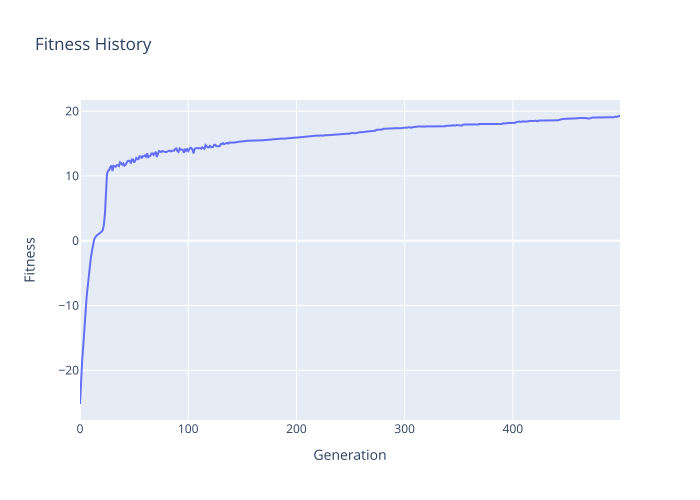

In [10]:
ga.fitness_plot()

In [11]:
ga.best_individual.shape

(128, 2)

#### Renderizado de la Melodía Final

MIDI file saved to: /Users/roicort/GitHub/MetaZoo/playgrounds/viEvolvedi/generated/melody_07-12-25-18.56.mid


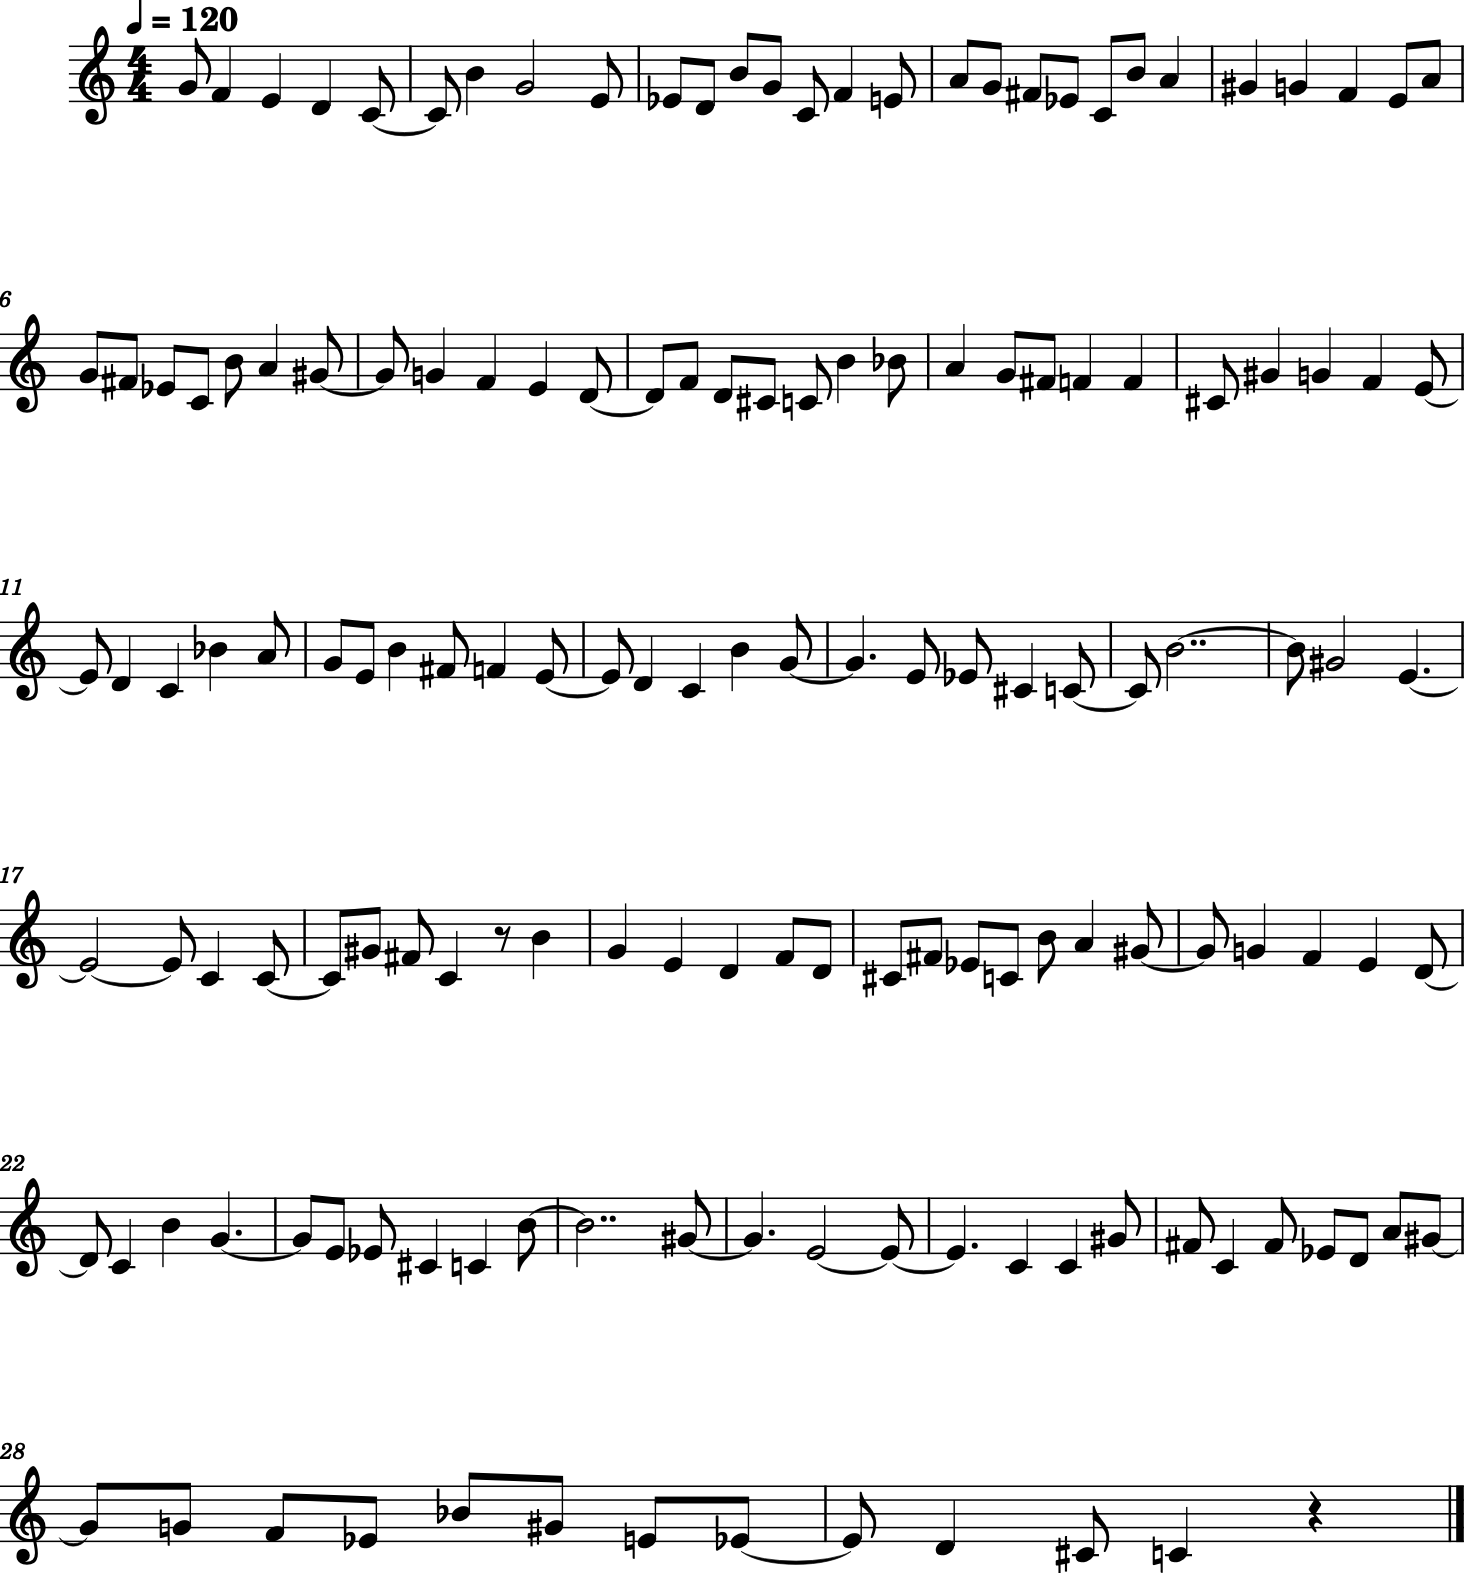

In [12]:
from datetime import datetime

melody = ga.best_individual
date = datetime.now().strftime("%d-%m-%y-%H.%M")
midi_path = os.path.join(SAVE_PATH, f"melody_{date}.mid")
midi_file = melody_to_midi(melody, filename=midi_path)
print(f"MIDI file saved to: {midi_path}")
score = converter.parse(midi_file)
score.show()

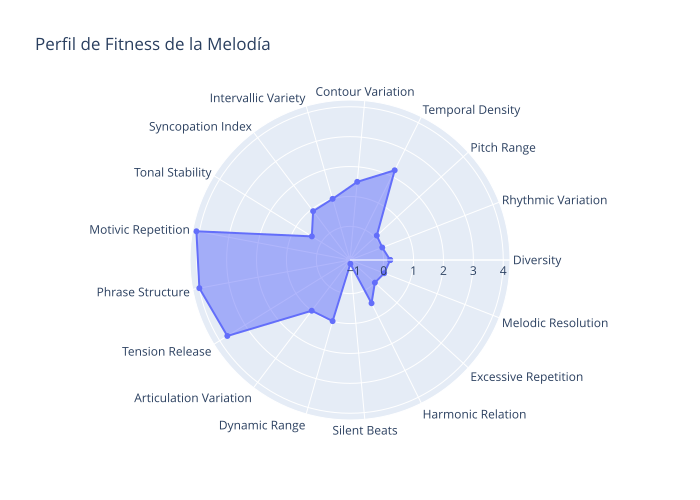

In [13]:
fitness.plot(melody)

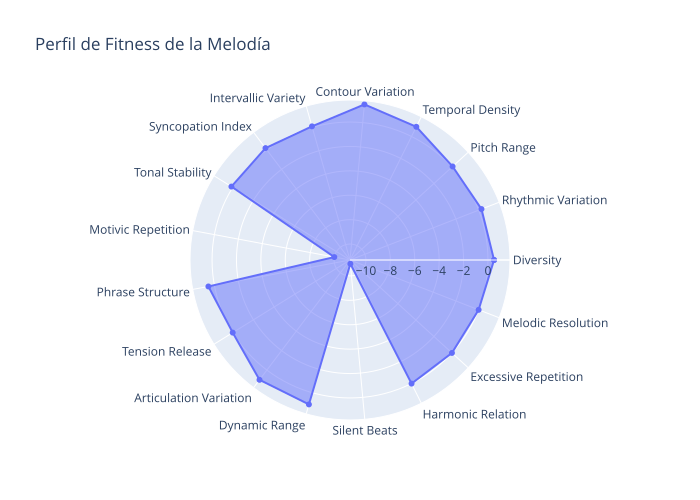

In [14]:
randompop = Population(population_size=1, encoding=encoding)
fitness.plot(randompop.individuals[-1])

#### Opcional: Conversión de MIDI a Audio

In [15]:
#from midi2audio import FluidSynth
#import os

#soundfont_path = "/opt/homebrew/Cellar/fluid-synth/2.5.1/share/soundfonts/default.sf2"

#fs = FluidSynth(sound_font=soundfont_path)
#fs.midi_to_audio(midi_path, midi_path.replace('.mid', '.flac'))

## Experimentos

Deseamos evaluar el impacto de diferentes parámetros del algoritmo genético en la calidad de las melodías generadas. Para ello, realizamos una serie de experimentos variando parámetros clave como el tamaño de la población, las tasas de cruce y mutación, y el elitismo. Así como la ejecución de múltiples corridas para evaluar la consistencia de los resultados.

In [31]:
RANDOM_SEEDS = [42, 56, 78, 91, 13, 27, 34, 65, 89, 100]
GENS = 100
POPSIZE = 100

In [32]:
# Comparemos tasas de mutación y cruce
import time

mutation_rates = [0.05, 0.1, 0.2, 0.3]
crossover_rates = [0.1, 0.5, 0.7, 0.9]
pop_sizes = [10, 50, 100, 200]
elitisms = [0.1, 0.2, 0.5, 0.9]

results = {}

for mut_rate in mutation_rates:
    for cross_rate in crossover_rates:
        for pop_size in pop_sizes:
            for eli in elitisms:
                ga = MelodyGA(
                    fitness_function=fitness.fitness_function,
                    selection_function=selection.tournament,
                    crossover_function=MelodyOperators.crossover,
                    mutation_function=MelodyOperators.mutation,
                    crossover_rate=cross_rate,
                    mutation_rate=mut_rate,
                    encoder=MelodyEncoding(note_range=(60, 72), length=128),
                    elitism=eli,
                    population_size=pop_size
                )
                start = time.time()
                ga.run(generations=GENS, verbose=False)
                ga_time = time.time() - start

                best_fitness = ga.best_fitness
                results[(mut_rate, cross_rate, pop_size, eli)] = [best_fitness, ga_time]

In [33]:
# Analicemos los resultados

import pandas as pd
import plotly.express as px
from rich.console import Console
from rich.table import Table

results_df = pd.DataFrame(
    [(mut, cross, pop, elitism, fit_time[0], fit_time[1]) for (mut, cross, pop, elitism), fit_time in results.items()],
    columns=['Mutation', 'Crossover', 'Population', 'Elitism', 'Best Fitness', 'Time (s)']
)

results_df.sort_values(['Best Fitness'], ascending=False)

console = Console()
table = Table(title="GA Rates Results")
table.add_column("Mutation", justify="right", style="cyan", no_wrap=True)
table.add_column("Crossover", justify="right", style="cyan", no_wrap=True)
table.add_column("Population", justify="right", style="cyan", no_wrap=True)
table.add_column("Elitism", justify="right", style="cyan", no_wrap=True)
table.add_column("Best Fitness", justify="right", style="magenta")
table.add_column("Time (s)", justify="right", style="green")
for index, row in results_df.sort_values(['Best Fitness'], ascending=False).iterrows():
    table.add_row(
        str(row['Mutation']),
        str(row['Crossover']),
        str(int(row['Population'])),
        f"{row['Elitism']:.2f}",
        f"{row['Best Fitness']:.4f}",
        f"{row['Time (s)']:.2f}"
    )
console.print(table)

                            GA Rates Results                             
┏━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Mutation ┃ Crossover ┃ Population ┃ Elitism ┃ Best Fitness ┃ Time (s) ┃
┡━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│     0.05 │       0.1 │        200 │    0.10 │      15.5290 │    17.88 │
│      0.3 │       0.7 │        200 │    0.10 │      15.3684 │    19.63 │
│      0.3 │       0.1 │        200 │    0.20 │      15.3393 │    17.30 │
│      0.3 │       0.5 │        200 │    0.10 │      15.3295 │    17.72 │
│      0.1 │       0.9 │        200 │    0.10 │      15.3208 │    17.48 │
│      0.2 │       0.1 │        200 │    0.10 │      15.3061 │    17.77 │
│      0.1 │       0.1 │        200 │    0.10 │      15.3018 │    18.83 │
│      0.3 │       0.5 │        200 │    0.20 │      15.3006 │    17.67 │
│      0.2 │       0.9 │        200 │    0.10 │      15.2084 │    18.56 │
│     0.05 │       0.7 │        200 │    0.20 │      15.1972 │    17.98 │
│      0.1 │       0.9 │        200 │    0.20 │      15.1769 │    18.09 │
│      0.1 │       0.5 │        200 │    0.10 │      15.1616 │    18.19 │
│      0.2 │       0.5 │        200 │    0.20 │      15.1593 │    17.99 │
│      0.3 │       0.7 │        200 │    0.20 │      15.1566 │    18.00 │
│     0.05 │       0.7 │        200 │    0.10 │      15.1220 │    18.57 │
│     0.05 │       0.1 │        100 │    0.20 │      15.1168 │     9.74 │
│      0.1 │       0.7 │        200 │    0.10 │      15.1068 │    17.31 │
│      0.2 │       0.7 │        200 │    0.20 │      15.0870 │    17.44 │
│      0.2 │       0.1 │        200 │    0.20 │      15.0686 │    18.40 │
│     0.05 │       0.9 │        200 │    0.10 │      15.0244 │    18.26 │
│      0.3 │       0.1 │        100 │    0.10 │      14.9858 │     9.17 │
│     0.05 │       0.5 │        200 │    0.20 │      14.9567 │    17.20 │
│      0.3 │       0.9 │        200 │    0.10 │      14.9545 │    17.39 │
│      0.2 │       0.7 │        100 │    0.20 │      14.9221 │     8.81 │
│      0.1 │       0.5 │        200 │    0.20 │      14.9172 │    18.28 │
│      0.2 │       0.1 │        100 │    0.20 │      14.8533 │     9.13 │
│     0.05 │       0.5 │        100 │    0.10 │      14.8252 │     8.56 │
│      0.2 │       0.7 │        200 │    0.10 │      14.7908 │    17.58 │
│     0.05 │       0.7 │        100 │    0.10 │      14.7773 │     8.82 │
│      0.1 │       0.7 │        200 │    0.20 │      14.7731 │    17.37 │
│      0.2 │       0.5 │        200 │    0.10 │      14.7696 │    18.79 │
│      0.2 │       0.7 │        100 │    0.10 │      14.7618 │     8.86 │
│      0.2 │       0.1 │        100 │    0.10 │      14.7349 │     9.26 │
│      0.1 │       0.7 │        100 │    0.20 │      14.6901 │     9.20 │
│     0.05 │       0.9 │        100 │    0.20 │      14.6768 │     9.53 │
│      0.1 │       0.5 │        100 │    0.10 │      14.6564 │     9.63 │
│      0.2 │       0.9 │        200 │    0.20 │      14.6559 │    18.87 │
│      0.3 │       0.9 │        100 │    0.10 │      14.6549 │     8.59 │
│     0.05 │       0.9 │        100 │    0.10 │      14.6395 │     9.53 │
│     0.05 │       0.5 │        100 │    0.20 │      14.6217 │     8.74 │
│      0.2 │       0.5 │        100 │    0.10 │      14.6164 │     9.09 │
│      0.3 │       0.7 │        200 │    0.50 │      14.5977 │    17.72 │
│      0.3 │       0.7 │        100 │    0.10 │      14.5969 │     8.84 │
│      0.1 │       0.1 │        200 │    0.20 │      14.5798 │    18.19 │
│     0.05 │       0.9 │        200 │    0.20 │      14.5779 │    18.47 │
│      0.3 │       0.9 │        200 │    0.20 │      14.5685 │    17.56 │
│      0.2 │       0.5 │        100 │    0.20 │      14.5669 │     9.08 │
│      0.3 │       0.1 │        200 │    0.10 │      14.5607 │    17.67 │
│     0.05 │       0.9 │        200 │    0.50 │      14.5502 │    19.33 │
│     0.05 │       0.1 │        200 │    0.20 │      14.5383 │    18.05 │
│   

Notamos que ciertos parámetros tienen un impacto significativo en la calidad de las melodías generadas. Por ejemplo, un tamaño de población más grande tiende a producir melodías más variadas, mientras que una tasa de mutación demasiado alta puede llevar a una pérdida de coherencia musical. Una tasa de cruce moderada parece ser óptima, ya que permite la combinación efectiva de características musicales sin introducir demasiada aleatoriedad. Un elitismo bajo ayuda a preservar las mejores melodías a lo largo de las generaciones, mejorando la convergencia del algoritmo.

In [34]:
import numpy as np

# Corremos múltiples semillas y guardamos las poblaciones

bests = {}
popmeans = {}

for seed in RANDOM_SEEDS:
    np.random.seed(seed)
    ga = MelodyGA(
        fitness_function=fitness.fitness_function,
        selection_function=selection.tournament,
        crossover_function=MelodyOperators.crossover,
        mutation_function=MelodyOperators.mutation,
        crossover_rate=0.7,
        mutation_rate=0.1,
        encoder=MelodyEncoding(note_range=(60, 72), length=128),
        elitism=0.1,
    )
    ga.run(generations=GENS, verbose=False, history=False)

    bests[seed] = ga.best_history
    popmeans[seed] = ga.fitness_history

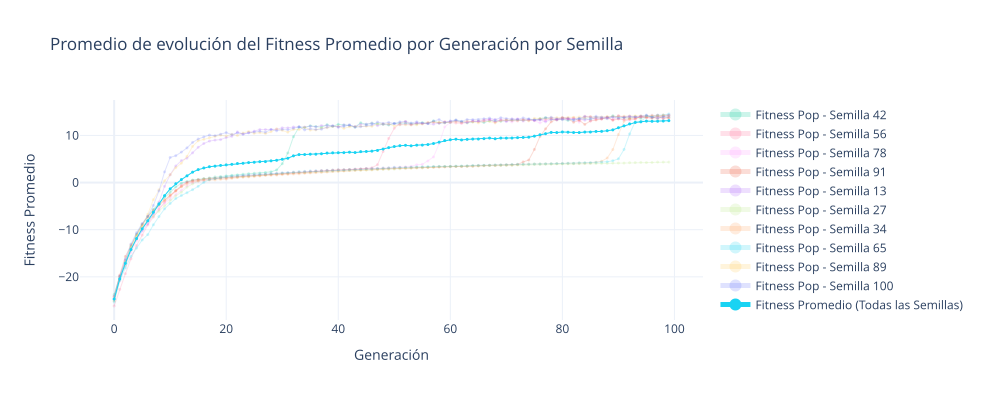

In [35]:
# Graficar, por generación, el fitness mínimo promedio 

import plotly.graph_objects as go
import matplotlib.colors as mcolors

fig = go.Figure()

for seed in RANDOM_SEEDS:
    seed_df = pd.Series(popmeans[seed], name="avg")
    hex_color = px.colors.qualitative.Plotly[seed % 10]
    rgba = mcolors.to_rgba(hex_color, alpha=0.2)
    rgba_str = f'rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]})'

    fig.add_trace(go.Scatter(
        x=seed_df.index,
        y=seed_df.values,
        mode='lines+markers',
        name=f'Fitness Pop - Semilla {seed}',
        line=dict(color=rgba_str)
    ))


mean_df = pd.DataFrame({
    'avg': pd.DataFrame(popmeans).mean(axis=1),
    'std': pd.DataFrame(popmeans).std(axis=1)
})   

fig.add_trace(go.Scatter(
    x=mean_df.index,
    y=mean_df['avg'],
    error_x=dict(type='data', array=mean_df['std'], visible=False),
    mode='lines+markers',
    name='Fitness Promedio (Todas las Semillas)',
    line=dict(color=px.colors.qualitative.Plotly[5], width=2)
))

fig.update_layout(
    title='Promedio de evolución del Fitness Promedio por Generación por Semilla',
    xaxis_title='Generación',
    yaxis_title='Fitness Promedio',
    template='plotly_white'
)

fig.update_traces(marker=dict(size=3))
fig.update_traces(line=dict(width=1))
fig.update_layout(legend=dict(itemsizing='constant'))
fig.update_layout(width=1000, height=400)
fig.show()


## Herramienta Creativa 

ViEVOLVEdi puede ser utilizado como una herramienta creativa para compositores que buscan inspiración o desean explorar nuevas ideas melódicas. 

Si bien esta propuesta tiene sus limitaciones como la subjetividad en la evaluación musical, la complejidad de capturar todos los matices de la música y no es capaz de componer en si misma reemplazando la creatvidad humana, ofrece un herramienta que sí puede complementarla al proporcionar nuevas posibilidades melódicas y fungir como asistencia de composición.

En este proyecto se ofrece también una herramienta web para la generación de melodías evolutivas utilizando ViEVOLVEdi. Esta herramienta permite a los usuarios configurar parámetros del algoritmo genético y generar melodías de manera interactiva, facilitando su uso como asistente de composición musical. Se puede encontrar en el siguiente enlace: [ViEVOLVEdi Web App](https://playgrounds.unknowable.xyz)

## Trabajo Futuro 

Hay un sin fin de posibilidades para expandir y mejorar este trabajo. Las agruparemos respecto a los algoritmos utililizados y respecto a la función objetivo.

### Algoritmos

Como mencionamos anteriormente, el uso de algoritmos evolutivos multiobjetivo como NSGA-II podría ser explorado para optimizar directamente múltiples aspectos musicales sin necesidad de combinarlos en una única función de aptitud. Esto permitiría una exploración más rica del espacio de soluciones y podría conducir a melodías que equilibran mejor los distintos criterios musicales.

Dado que este es un problema de alguna manera simbólico, otra línea de trabajo futuro es explorar el uso de algoritmos basados en programación genética (GP). La GP podría permitir la evolución de estructuras musicales más complejas y jerárquicas, capturando mejor la naturaleza estructurada de la música. Trabajos como el de Johanson et al. (2001) han demostrado el potencial de la GP en la generación musical, y podría ser interesante comparar su desempeño con los algoritmos genéticos tradicionales en este contexto.

### Función Objetivo

No obstante el uso de algoritmos como NSGA-II aún depende de una función objetivo bien definida en función de los aspectos musicales que queremos optimizar. En este sentido, seguimos dependiendo de métricas musicales que, aunque basadas en teoría musical, pueden no capturar completamente la percepción subjetiva de la calidad musical. 

Una posible dirección futura es incorporar retroalimentación humana directa en el proceso evolutivo, permitiendo a los usuarios evaluar las melodías generadas y guiar la evolución hacia soluciones que resuenen mejor con las preferencias humanas. 

Una alternativa interesante es el uso de modelos de IA entrenados en grandes conjuntos de datos musicales (como MusicTransformers) para evaluar la calidad musical. Estos modelos podrían capturar patrones y características musicales complejas que son difíciles de cuantificar mediante métricas tradicionales, proporcionando una evaluación más alineada con la percepción humana de la música. Usar estos modelos como función objetivo podría mejorar significativamente la calidad de las melodías generadas por el algoritmo evolutivo.

# Conclusiones

En este trabajo, hemos explorado el uso de algoritmos genéticos para la generación automática de melodías musicales, definiendo una representación adecuada, operadores genéticos específicos y una función objetivo compuesta por múltiples aspectos musicales. Los resultados muestran que el enfoque evolutivo puede producir melodías que mejoran en calidad a lo largo de las generaciones, aunque aún existen numerosos desafíos y oportunidades para mejorar tanto los algoritmos como la evaluación musical como aquellos mencionados en la sección de trabajo futuro.

No obstante estas propuestas como ViEVOLVEdi ofrecen herramientas interesantísimas para la asistencia en la composición musical, abriendo nuevas posibilidades para la creatividad humana asistida por IA. Qué a mi parecer es además una manera ética y responsable de utilizar la inteligencia artificial en el arte.

# Referencias

- Horner, A., & Goldberg, D. E. (1991). Genetic algorithms and computer-assisted music composition. In *Proceedings of the 17th International Computer Music Conference, ICMC 1991 - Montreal, Canada* (pp. 431-437). Publisher NeXT Computer Inc.

- Johanson, T., & Poli, R. (2004). GP-Music: An interactive genetic programming system for music generation with automated fitness raters. In *Applications of Evolutionary Computing* (pp. 647-656). Springer, Berlin, Heidelberg.

# Librerías 

Gracias a las siguientes librerías de código abierto que facilitaron el desarrollo de este proyecto:

- [MetaZoo](https://github.com/MetaZoo/MetaZoo)
- [MIDIUtil](https://github.com/MarkCWirt/MIDIUtil) 
- [music21](www.music21.org)
- [plotly](https://plotly.com/python/)